# Steam Game Similarity Graph - Community Detection
**Course:** Graph Algorithms | **Instructor:** Dr. Avner Friel

**Students:** Yanir Karpis,Chen Brown,Shaked Rosenberg

**Research Question:** Do communities that emerge naturally from player behavior align with Steam's official genre classifications?

**Pipeline:** Install -> Load data -> Genre matching -> Build graph -> Community detection -> Centrality -> Visualize -> NMI

In [ ]:
# Install all required packages
# python-louvain : Louvain community detection algorithm
# thefuzz        : fuzzy string matching (for genre lookup)
# networkx       : graph construction and graph algorithms
# scikit-learn   : NMI evaluation metric
!pip install -q gdown python-louvain thefuzz[speedup] networkx matplotlib scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.7 MB/s eta 0:00:00


In [ ]:
# Import all libraries used throughout the notebook
import pandas as pd
import json
import zipfile
import os
import re
import gdown
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import community as community_louvain
from thefuzz import process as fuzz_process
from collections import defaultdict, Counter
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

print('All imports successful')

All imports successful


In [ ]:
# Download the dataset from Google Drive
# Contains: steam-200k.csv (user play behavior) and games.json (game genres)
DATA_DIR = '/content/steam dataset project'

folder_id = '1CPsdP4JfE8WzDt2Rj5gOf8S5fQKXPcs5'
gdown.download_folder(
    f'https://drive.google.com/drive/folders/{folder_id}',
    quiet=False,
    use_cookies=False
)

# Extract zip files inside the downloaded folder
for zname in ['steam dataset.zip', 'steam dataset tags 2.zip']:
    zpath = f'{DATA_DIR}/{zname}'
    if os.path.exists(zpath):
        with zipfile.ZipFile(zpath, 'r') as z:
            z.extractall(DATA_DIR)
        print(f'Extracted: {zname}')

Retrieving folder contents


Processing file 1H54_VLWXxTF4xq7gUsA_6OEZGPWdx-m8 steam dataset tags 2.zip
Processing file 1e_vrwaJsD8wkl3WSrCgnNm_eau_OA1p1 steam dataset.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1H54_VLWXxTF4xq7gUsA_6OEZGPWdx-m8
From (redirected): https://drive.google.com/uc?id=1H54_VLWXxTF4xq7gUsA_6OEZGPWdx-m8&confirm=t&uuid=94be15e0-72ec-45eb-9dff-db794d8c94e4
To: /content/steam dataset project/steam dataset tags 2.zip
100%|██████████| 283M/283M [00:04<00:00, 66.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1e_vrwaJsD8wkl3WSrCgnNm_eau_OA1p1
To: /content/steam dataset project/steam dataset.zip
100%|██████████| 1.53M/1.53M [00:00<00:00, 12.0MB/s]
Download completed


Extracted: steam dataset.zip
Extracted: steam dataset tags 2.zip


In [ ]:
# Load the main Steam dataset
# Each row = one user-game interaction: user_id, game_title, behavior (play/purchase), hours
df = pd.read_csv(
    f'{DATA_DIR}/steam-200k.csv',
    header=None,
    names=['user_id', 'game_title', 'behavior', 'hours', 'extra']
)

# Keep only 'play' rows (ignore purchase-only records)
df_play = df[df['behavior'] == 'play'].copy()

# If a user has multiple entries for the same game, keep the highest hours
df_play = df_play.sort_values('hours', ascending=False)
df_play = df_play.drop_duplicates(subset=['user_id', 'game_title'], keep='first')

print(f'Play rows    : {len(df_play):,}')
print(f'Unique users : {df_play["user_id"].nunique():,}')
print(f'Unique games : {df_play["game_title"].nunique():,}')
df_play.head()

Play rows    : 70,477
Unique users : 11,350
Unique games : 3,600


,user_id,game_title,behavior,hours,extra
123726,73017395,Sid Meier's Civilization V,play,11754.0,0
112643,100630947,Dota 2,play,10442.0,0
187005,153382649,Team Fortress 2,play,9640.0,0
165596,130882834,Dota 2,play,7765.0,0
183461,52567955,Dota 2,play,6964.0,0


In [ ]:
import pandas as pd
import json
import os

# Load the tag database from games.json.
# Strategy: use the highest-voted community tag as the primary label.
# We block mode/platform and aesthetic tags, then consolidate the remaining
# granular tags into 15 broad genre buckets via TAG_CONSOLIDATION.
# Fall back to genres[0] if a game has no usable tags.

META_TAGS = {
    # Play mode / multiplayer format
    "Singleplayer", "Multiplayer", "Co-op", "Online Co-Op", "Local Co-Op",
    "PvP", "PvE", "Tutorial", "Family Friendly", "2D", "3D",
    "First-Person", "Third Person", "Early Access",
    "Free to Play",
    "Indie",
    "VR",
    # Aesthetic / tone descriptors
    "Comedy", "Funny", "Cute", "Colorful", "Stylized", "Anime",
    "Atmospheric", "Dark", "Relaxing", "Difficult", "Pixel Graphics",
    "Retro", "Great Soundtrack", "Short", "Linear", "Violent", "Mature",
    "Sexual Content", "Nudity", "Gore",
    # Non-game software
    "Utilities", "Software", "Game Development", "Education",
    "Audio Production", "Video Production", "Animation & Modeling",
    "Photo Editing", "Documentary",
}

# Consolidation map: granular tags → one of 15 broad genre buckets
TAG_CONSOLIDATION = {
    # → Shooter
    "FPS": "Shooter", "Hero Shooter": "Shooter", "Military": "Shooter",
    "Tactical": "Shooter", "Battle Royale": "Shooter",
    # → RPG
    "Action RPG": "RPG", "JRPG": "RPG", "Loot": "RPG",
    "Dark Fantasy": "RPG", "MMORPG": "RPG",
    # → Action
    "Beat 'em up": "Action", "Action-Adventure": "Action",
    "Cyberpunk": "Action", "Medieval": "Action",
    "Hack and Slash": "Action", "Action Roguelike": "Action",
    "Rogue-like": "Action",
    # → Strategy
    "Turn-Based Strategy": "Strategy", "Tower Defense": "Strategy",
    "Warhammer 40K": "Strategy", "4X": "Strategy",
    "Real Time Tactics": "Strategy", "Grand Strategy": "Strategy",
    # → Survival
    "Zombies": "Survival", "Open World Survival Craft": "Survival",
    "Post-apocalyptic": "Survival",
    # → Platformer
    "Precision Platformer": "Platformer", "Puzzle-Platformer": "Platformer",
    "2D Platformer": "Platformer", "Side Scroller": "Platformer",
    # → Adventure
    "Narration": "Adventure", "Exploration": "Adventure",
    "Visual Novel": "Adventure",
    # → Simulation
    "Driving": "Simulation", "Football (Soccer)": "Simulation",
    "Racing": "Simulation", "Sports": "Simulation",
    "Trains": "Simulation", "Flight": "Simulation",
    "Space": "Simulation",
    # → Horror
    "Psychological Horror": "Horror",
}

with open(f"{DATA_DIR}/games.json", "r") as f:
    raw_json = json.load(f)

games_list = []
for app_id, info in raw_json.items():
    name   = info.get("name", "")
    tags   = info.get("tags",   {})
    genres = info.get("genres", [])

    if not name:
        continue

    # Pick the highest-voted tag that is not a meta/aesthetic tag
    primary = None
    if isinstance(tags, dict) and tags:
        for tag in sorted(tags, key=tags.get, reverse=True):
            if tag not in META_TAGS:
                primary = tag
                break

    # Fall back to genres[0] if no usable tag found
    if primary is None and genres:
        primary = genres[0]

    if primary:
        primary = TAG_CONSOLIDATION.get(primary, primary)
        games_list.append({"name": name, "genre": primary})

df_tags = pd.DataFrame(games_list)
print(f"Tag database: {df_tags['name'].nunique():,} unique games  ({len(df_tags):,} rows)")
print(f"Top tags:\n{df_tags['genre'].value_counts().head(20)}")

Tag database: 113,182 unique games  (114,304 rows)
Top tags:
genre
Action                   28240
Casual                   20980
Adventure                18668
Simulation                7358
Strategy                  5713
RPG                       5005
Indie                     2883
Horror                    2345
Platformer                2249
Puzzle                    1733
Shooter                    964
Survival                   729
Design & Illustration      460
Free To Play               394
Arcade                     369
Hidden Object              363
3D Platformer              318
Shoot 'Em Up               309
Massively Multiplayer      306
Story Rich                 302
Name: count, dtype: int64


In [ ]:
# Match game titles between the two datasets to assign a genre/tag label.
# Problem: titles differ slightly in punctuation, spacing, capitalization.
# Solution: three-pass matching
#   Pass 1 - exact match after cleaning (lowercase + strip punctuation)
#   Pass 2 - fuzzy match on the tag-based lookup (score >= 90, length ratio >= 0.4)
#   Pass 3 - genre-only fallback for still-unmatched games (recovers dropped games)

def clean_name(name):
    name = str(name).lower().strip()
    name = re.sub(r"[^\w\s]", "", name)
    name = re.sub(r"\s+", " ", name)
    return name

# Build clean-name -> tag label lookup (majority vote handles duplicate cleaned names)
df_tags["name_clean"] = df_tags["name"].apply(clean_name)
tag_lookup = (
    df_tags.groupby("name_clean")["genre"]
           .agg(lambda x: x.value_counts().index[0])
)

# Pass 1: exact match after cleaning
df_play["name_clean"] = df_play["game_title"].apply(clean_name)
df_play["genre"] = df_play["name_clean"].map(tag_lookup)

unmatched_titles = df_play[df_play["genre"].isna()]["game_title"].drop_duplicates().tolist()
print(f"Pass 1 (exact)  -> matched: {df_play['game_title'][df_play['genre'].notna()].nunique():,}  unmatched: {len(unmatched_titles):,}")

# Pass 2: fuzzy match on tag-based lookup
FUZZY_CUTOFF  = 90
MIN_LEN_RATIO = 0.4  # rejects short garbage matches like "eon" -> "napoleon total war"
MIN_NAME_LEN  = 4

tag_name_list = tag_lookup.index.tolist()
fuzzy_map = {}

for title in tqdm(unmatched_titles, desc="Pass 2 (fuzzy tag)"):
    q = clean_name(title)
    if len(q) < MIN_NAME_LEN:
        continue
    result = fuzz_process.extractOne(q, tag_name_list, score_cutoff=FUZZY_CUTOFF)
    if result:
        matched_name = result[0]
        len_ratio = min(len(q), len(matched_name)) / max(len(q), len(matched_name))
        if len_ratio >= MIN_LEN_RATIO:
            fuzzy_map[title] = tag_lookup.get(matched_name)

df_play["genre"] = df_play.apply(
    lambda r: r["genre"] if pd.notna(r["genre"]) else fuzzy_map.get(r["game_title"]),
    axis=1
)

still_unmatched = df_play[df_play["genre"].isna()]["game_title"].drop_duplicates().tolist()
print(f"Pass 2 (fuzzy)  -> matched: {df_play['game_title'][df_play['genre'].notna()].nunique():,}  unmatched: {len(still_unmatched):,}")

# Pass 3: genre-only fallback for games still without a label
# Uses the raw genres field from games.json as a last resort.
# This recovers games that failed fuzzy tag matching but have a valid genre entry.
genre_fallback_lookup = {}
for app_id, info in raw_json.items():
    name   = info.get("name", "")
    genres = info.get("genres", [])
    if name and genres:
        cn = clean_name(name)
        if cn not in genre_fallback_lookup:
            genre_fallback_lookup[cn] = genres[0]

genre_fallback_names = list(genre_fallback_lookup.keys())
fallback_map = {}

for title in tqdm(still_unmatched, desc="Pass 3 (genre fallback)"):
    q = clean_name(title)
    if len(q) < MIN_NAME_LEN:
        continue
    if q in genre_fallback_lookup:
        fallback_map[title] = genre_fallback_lookup[q]
        continue
    result = fuzz_process.extractOne(q, genre_fallback_names, score_cutoff=FUZZY_CUTOFF)
    if result:
        matched_name = result[0]
        len_ratio = min(len(q), len(matched_name)) / max(len(q), len(matched_name))
        if len_ratio >= MIN_LEN_RATIO:
            fallback_map[title] = genre_fallback_lookup[matched_name]

df_play["genre"] = df_play.apply(
    lambda r: r["genre"] if pd.notna(r["genre"]) else fallback_map.get(r["game_title"]),
    axis=1
)

matched = df_play["game_title"][df_play["genre"].notna()].nunique()
total   = df_play["game_title"].nunique()
print(f"Pass 3 (fallback)-> matched: {matched:,} / {total:,}  ({matched/total*100:.1f}%)")
print(f"\nTop labels in dataset:\n{df_play['genre'].value_counts().head(20)}")

print(f"\nFuzzy tag matches: {len(fuzzy_map)}  |  Genre fallback matches: {len(fallback_map)}")
print(f"\n{'Original title':<45} {'Matched title':<45} {'Score':>5}  Label")
print("-" * 110)
for orig in list(fuzzy_map.keys())[:20]:
    q    = clean_name(orig)
    best = fuzz_process.extractOne(q, tag_name_list)
    print(f"{orig:<45} {best[0] if best else 'N/A':<45} {best[1] if best else 0:>5}  {fuzzy_map[orig]}")

Pass 1 (exact)  -> matched: 2,509  unmatched: 1,091


Pass 2 (fuzzy tag):   0%|          | 0/1091 [00:00<?, ?it/s]

Pass 2 (fuzzy)  -> matched: 2,926  unmatched: 674


Pass 3 (genre fallback):   0%|          | 0/674 [00:00<?, ?it/s]

Pass 3 (fallback)-> matched: 3,007 / 3,600  (83.5%)

Top labels in dataset:
genre
Action                   11697
Shooter                   7789
Survival                  5808
Strategy                  5153
MOBA                      5040
RPG                       4485
Simulation                3815
Open World                3714
Adventure                 1482
Puzzle                    1419
Casual                    1283
Platformer                1105
Horror                     994
Sandbox                    747
Stealth                    694
Fighting                   381
Clicker                    377
City Builder               331
Massively Multiplayer      277
Dinosaurs                  177
Name: count, dtype: int64

Fuzzy tag matches: 417  |  Genre fallback matches: 81

Original title                                Matched title                                 Score  Label
--------------------------------------------------------------------------------------------------------------


In [ ]:
# Build the game-similarity graph
# Node  = a game (only games that have a known genre)
# Edge  = two games share at least MIN_SHARED_PLAYERS common players
# Weight = exact number of shared players (stronger connection = more shared players)

MIN_SHARED_PLAYERS = 25  # raised from 10 → sparser graph → cleaner, better-separated communities

# Only use games that have a genre label
df_g = df_play[df_play['genre'].notna()].copy()

# Group by user: get the set of games each user played
user_games = df_g.groupby('user_id')['game_title'].apply(set)

# Count shared players for every pair of games
pair_counts = defaultdict(int)
for games in user_games:
    games = list(games)
    for i in range(len(games)):
        for j in range(i + 1, len(games)):
            # Use sorted tuple so (A,B) and (B,A) count as the same pair
            pair = (min(games[i], games[j]), max(games[i], games[j]))
            pair_counts[pair] += 1

print(f'Total co-play pairs found: {len(pair_counts):,}')

# Create the graph and add nodes with genre attribute
G = nx.Graph()
game_genre = df_g[['game_title','genre']].drop_duplicates('game_title').set_index('game_title')['genre']
for game, genre in game_genre.items():
    G.add_node(game, genre=genre)

# Add edges only if shared players >= threshold
for (g1, g2), w in pair_counts.items():
    if w >= MIN_SHARED_PLAYERS and G.has_node(g1) and G.has_node(g2):
        G.add_edge(g1, g2, weight=w)

# Keep only the largest connected component (fully connected subgraph)
lcc = max(nx.connected_components(G), key=len)
G = G.subgraph(lcc).copy()

print(f'Graph: {G.number_of_nodes():,} nodes  |  {G.number_of_edges():,} edges')
print(f'Avg degree: {sum(d for _, d in G.degree()) / G.number_of_nodes():.1f}')

Total co-play pairs found: 636,790
Graph: 333 nodes  |  4,617 edges
Avg degree: 27.7


In [ ]:
import time
from community.community_louvain import best_partition, modularity

# Community Detection - Louvain Algorithm
# Louvain maximizes modularity: it finds groups where games are more connected
# to each other than to the rest of the graph.
# resolution > 1.0 prefers smaller, more granular communities (default = 1.0).
# We use resolution=1.5 to break apart the large merged blobs.

t0 = time.time()
louvain_partition = best_partition(G, weight='weight', random_state=42, resolution=1.5)
louvain_time = time.time() - t0

nx.set_node_attributes(G, louvain_partition, 'louvain')
n_communities = len(set(louvain_partition.values()))
louvain_mod = modularity(louvain_partition, G, weight='weight')

print(f'Louvain found {n_communities} communities in {louvain_time:.2f}s')
print(f'Modularity score: {louvain_mod:.4f}')
print()

sizes = Counter(louvain_partition.values())
for cid, size in sorted(sizes.items()):
    print(f'  Community {cid}: {size} games')

Louvain found 16 communities in 0.05s
Modularity score: 0.1117

  Community 0: 25 games
  Community 1: 20 games
  Community 2: 5 games
  Community 3: 9 games
  Community 4: 16 games
  Community 5: 52 games
  Community 6: 9 games
  Community 7: 11 games
  Community 8: 6 games
  Community 9: 12 games
  Community 10: 18 games
  Community 11: 80 games
  Community 12: 17 games
  Community 13: 9 games
  Community 14: 36 games
  Community 15: 8 games


In [ ]:
# Community Detection - Girvan-Newman Algorithm
# Girvan-Newman repeatedly removes the edge with highest betweenness centrality
# (the edge used by the most shortest paths), which splits the graph into clusters
# We stop when we reach the same number of communities as Louvain (for fair comparison)

from networkx.algorithms.community import girvan_newman
import itertools
from community.community_louvain import modularity

print(f'Running Girvan-Newman (target: {n_communities} communities)...')
print('NOTE: Girvan-Newman is O(m^2 * n) -- this may take several minutes on a dense graph.')

t0 = time.time()
gn_gen = girvan_newman(G)
# Each next() call splits one more community.
# After k next() calls we have k+1 communities, so to reach n_communities we need n_communities-1 calls.
gn_communities = next(itertools.islice(gn_gen, n_communities - 2, None))
gn_time = time.time() - t0

# Convert list-of-sets into a node -> community_id dictionary
gn_partition = {}
for cid, node_set in enumerate(gn_communities):
    for node in node_set:
        gn_partition[node] = cid

nx.set_node_attributes(G, gn_partition, 'girvan_newman')
gn_mod = modularity(gn_partition, G, weight='weight')

print(f'Girvan-Newman done: {len(set(gn_partition.values()))} communities in {gn_time:.1f}s')
print(f'Modularity score: {gn_mod:.4f}')
print()
print(f'Runtime — Louvain: {louvain_time:.2f}s  |  Girvan-Newman: {gn_time:.1f}s')

Running Girvan-Newman (target: 16 communities)...
NOTE: Girvan-Newman is O(m^2 * n) -- this may take several minutes on a dense graph.
Girvan-Newman done: 16 communities in 11.9s
Modularity score: -0.0000

Runtime — Louvain: 0.05s  |  Girvan-Newman: 11.9s


In [ ]:
# Centrality Analysis
# PageRank    : measures how 'important' a game is - games played alongside many
#               other popular games score higher
# Betweenness : measures how often a game sits on the shortest path between two
#               other games - high betweenness = bridge between communities
#
# NOTE: betweenness is computed WITHOUT edge weights on purpose.
# nx.betweenness_centrality(weight=...) treats weight as *distance* (cost),
# so passing shared-player counts would make popular connections look *farther*
# apart - the opposite of what we want. Topology alone captures bridging correctly.

print('Computing PageRank...')
pagerank = nx.pagerank(G, weight='weight')

print('Computing Betweenness Centrality...')
betweenness = nx.betweenness_centrality(G, normalized=True)   # unweighted - weight as distance is backwards here

# Store as node attributes
nx.set_node_attributes(G, pagerank,    'pagerank')
nx.set_node_attributes(G, betweenness, 'betweenness')

# Build a summary dataframe for easy inspection
centrality_df = pd.DataFrame([
    {
        'game'       : n,
        'genre'      : G.nodes[n]['genre'],
        'community'  : louvain_partition[n],
        'pagerank'   : round(pagerank[n], 6),
        'betweenness': round(betweenness[n], 6)
    }
    for n in G.nodes
])

print('\nTop 15 games by PageRank:')
print(centrality_df.sort_values('pagerank', ascending=False).head(15).to_string(index=False))

print('\nTop 15 games by Betweenness Centrality:')
print(centrality_df.sort_values('betweenness', ascending=False).head(15).to_string(index=False))

Computing PageRank...
Computing Betweenness Centrality...

Top 15 games by PageRank:
                           game      genre  community  pagerank  betweenness
                Team Fortress 2    Shooter         11  0.058052     0.285045
                         Dota 2       MOBA          4  0.036858     0.107741
Counter-Strike Global Offensive     Action          6  0.036616     0.078470
                  Left 4 Dead 2   Survival         10  0.034305     0.083276
     The Elder Scrolls V Skyrim Open World          5  0.033935     0.122195
                    Garry's Mod    Sandbox         11  0.023598     0.029167
                       Portal 2     Puzzle          9  0.022014     0.037352
                       Unturned   Survival         11  0.021256     0.043356
                       Terraria   Survival         15  0.019771     0.022379
                  Borderlands 2        RPG          2  0.019518     0.025750
     Sid Meier's Civilization V   Strategy          5  0.017472     

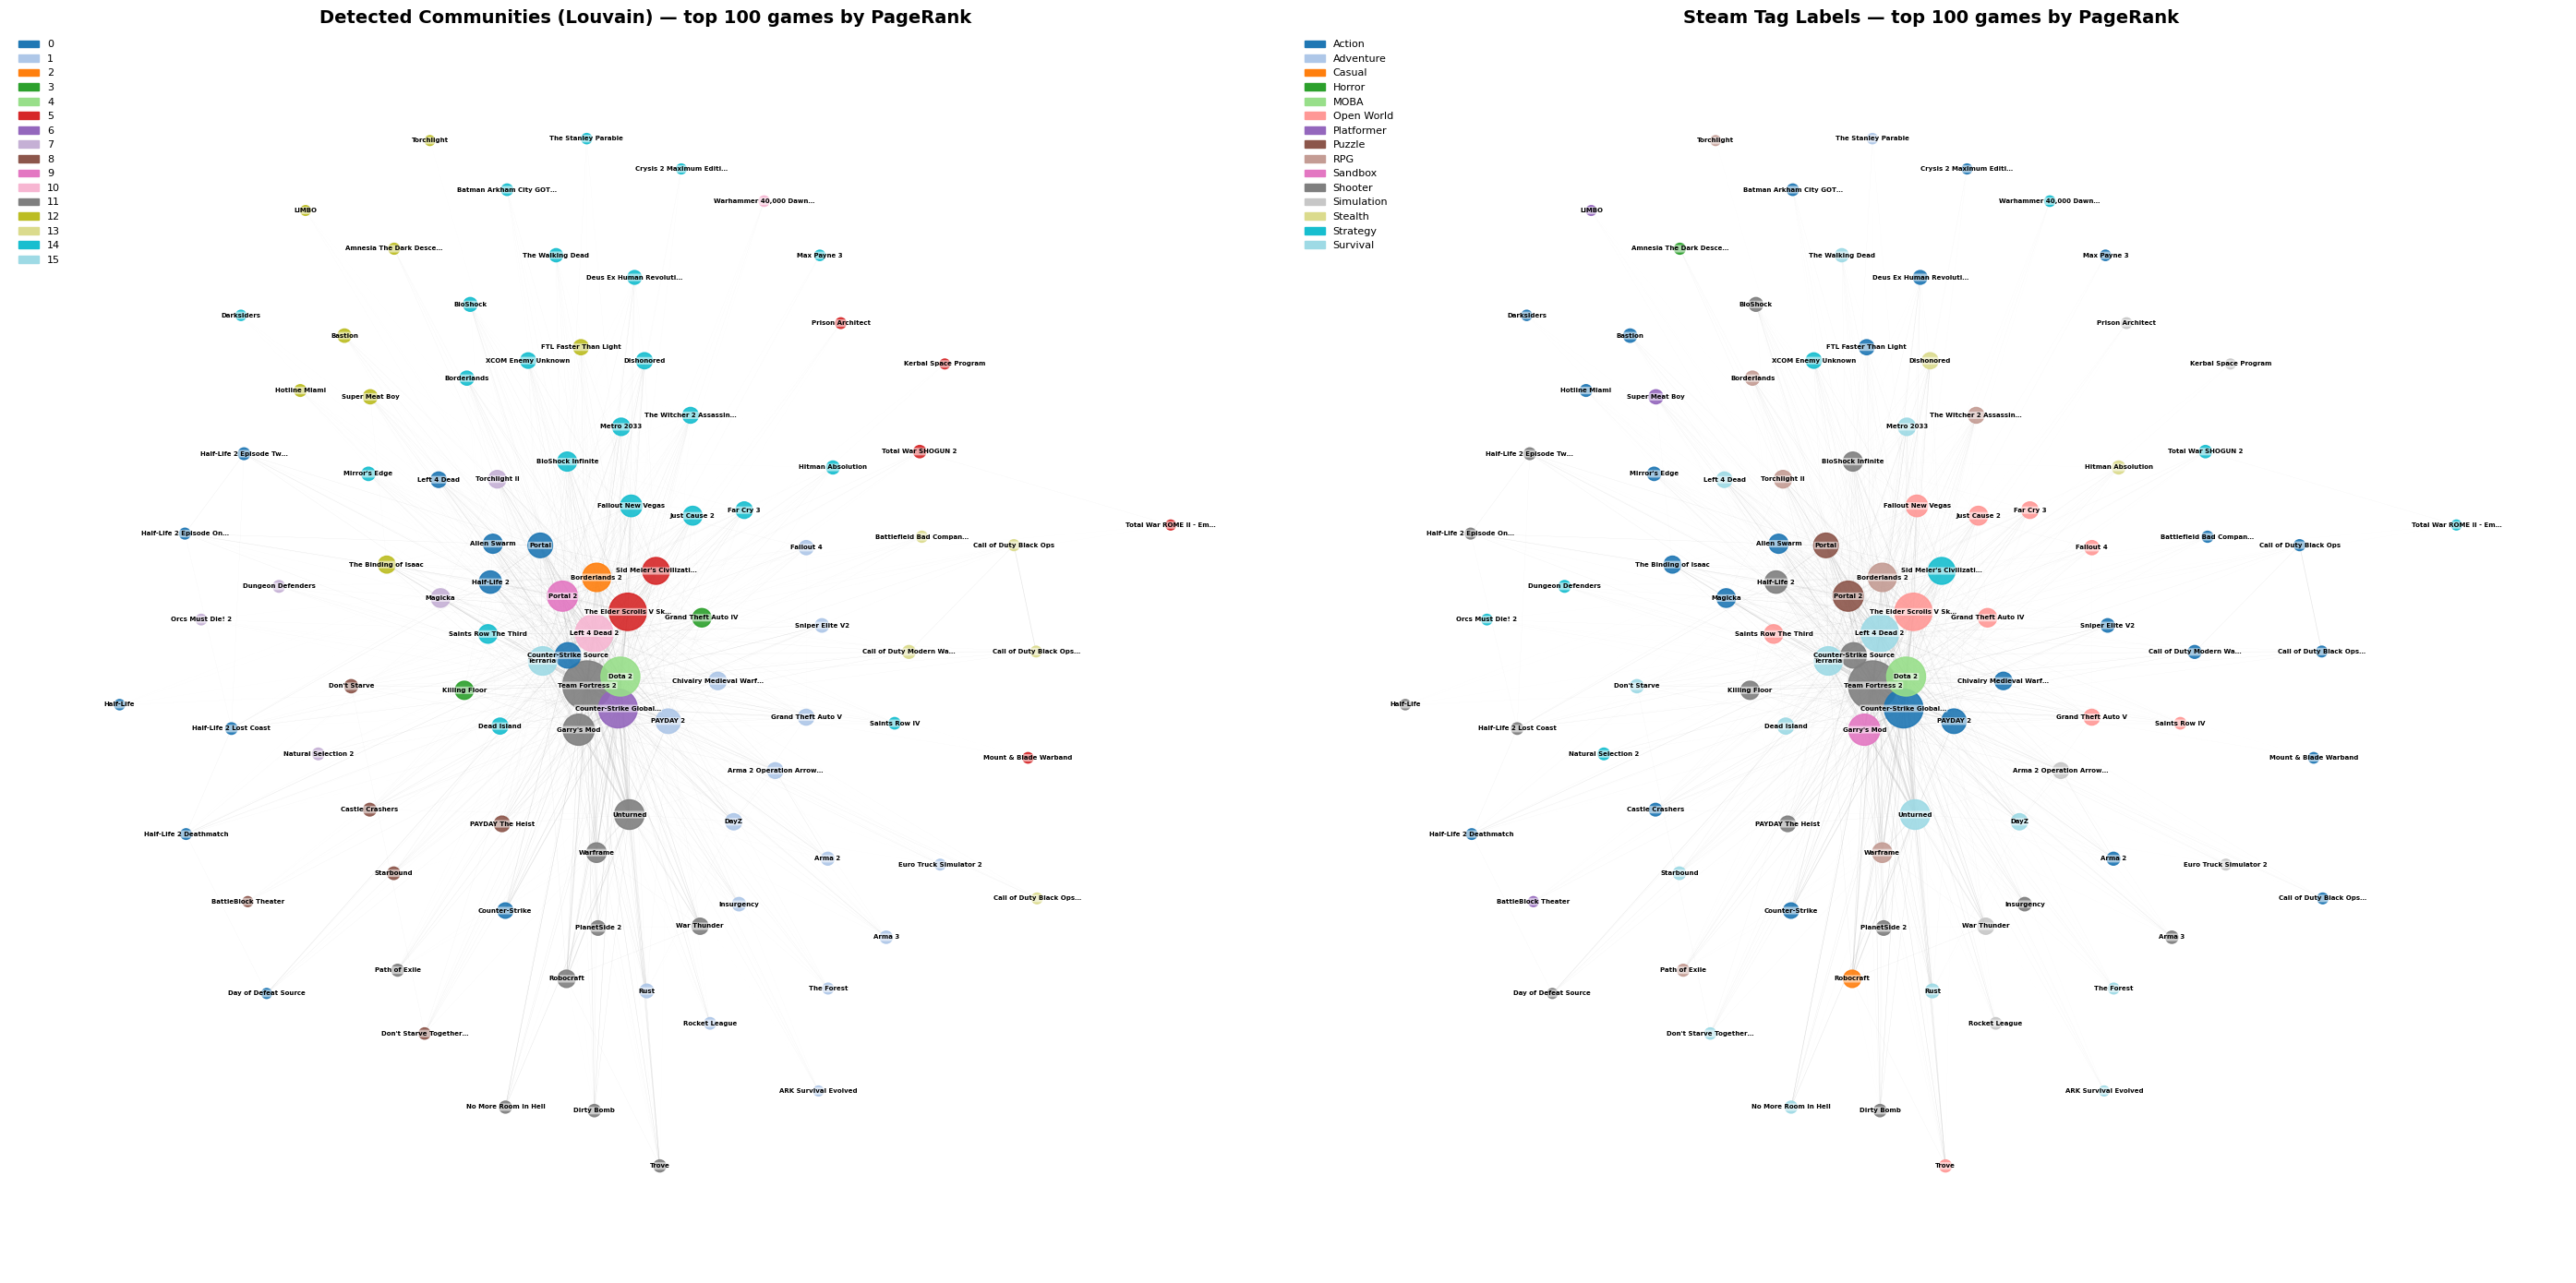

Nodes: 100  |  Edges drawn (weight>=50): 1041  |  Total edges in subgraph: 2748


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import networkx as nx
import math

# Show top 100 nodes by PageRank (slightly fewer = more breathing room in layout)
TOP_N        = 100
EDGE_MIN_W   = 50   # only DRAW edges with 50+ shared players (keeps picture clean)
               # community detection still uses ALL edges — this is display-only

top_nodes = sorted(pagerank, key=pagerank.get, reverse=True)[:TOP_N]
Gv        = G.subgraph(top_nodes).copy()

def short_label(name, max_len=22):
    return name if len(name) <= max_len else name[:max_len].rstrip() + '…'

def draw_graph(Gv, pos, color_attr, title, ax):
    vals        = [Gv.nodes[n][color_attr] for n in Gv.nodes]
    unique_vals = sorted(set(vals))
    cmap        = plt.colormaps["tab20"].resampled(len(unique_vals))
    color_map   = {v: cmap(i) for i, v in enumerate(unique_vals)}
    node_colors = [color_map[v] for v in vals]

    # Only draw strong edges — weaker ones exist in the graph but clutter the picture
    strong_edges = [(u, v) for u, v in Gv.edges() if Gv[u][v]["weight"] >= EDGE_MIN_W]
    weights      = np.array([Gv[u][v]["weight"] for u, v in strong_edges]) if strong_edges else np.array([])
    w_norm       = (weights - weights.min()) / (weights.max() - weights.min() + 1e-9) * 2.5 if len(weights) else []

    nx.draw_networkx_edges(Gv, pos, edgelist=strong_edges, ax=ax,
                           alpha=0.3, width=w_norm, edge_color="#aaaaaa")
    nx.draw_networkx_nodes(
        Gv, pos, ax=ax,
        node_color=node_colors,
        node_size=[pagerank[n] * 25000 for n in Gv.nodes],
        alpha=0.9
    )
    labels = {n: short_label(n) for n in Gv.nodes}
    nx.draw_networkx_labels(
        Gv, pos, labels=labels, ax=ax,
        font_size=5, font_weight="bold", font_color="black",
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.55, edgecolor="none")
    )
    patches = [mpatches.Patch(color=color_map[v], label=str(v)) for v in unique_vals]
    ax.legend(handles=patches, loc="upper left", bbox_to_anchor=(0.0, 1.0),
              fontsize=8, ncol=1, frameon=False)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")

# Community-seeded layout — places each node near its community's center on a circle
# so spring layout starts with clusters separated instead of collapsing to a blob
community_ids = sorted(set(louvain_partition.values()))
n_comm        = len(community_ids)
np.random.seed(42)

community_centers = {
    cid: np.array([3.0 * math.cos(2 * math.pi * i / n_comm),
                   3.0 * math.sin(2 * math.pi * i / n_comm)])
    for i, cid in enumerate(community_ids)
}

pos_init = {
    node: community_centers[louvain_partition[node]] + np.random.randn(2) * 0.4
    for node in Gv.nodes
}

pos = nx.spring_layout(Gv, pos=pos_init, seed=42, k=1.2, iterations=150, weight="weight")

fig, axes = plt.subplots(1, 2, figsize=(28, 14))
draw_graph(Gv, pos, "louvain", f"Detected Communities (Louvain) — top {TOP_N} games by PageRank", axes[0])
draw_graph(Gv, pos, "genre",   f"Steam Tag Labels — top {TOP_N} games by PageRank",               axes[1])
plt.tight_layout()
plt.savefig("/content/graph_comparison_improved.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Nodes: {TOP_N}  |  Edges drawn (weight>={EDGE_MIN_W}): {sum(1 for u,v in Gv.edges() if Gv[u][v]['weight']>=EDGE_MIN_W)}"
      f"  |  Total edges in subgraph: {Gv.number_of_edges()}")

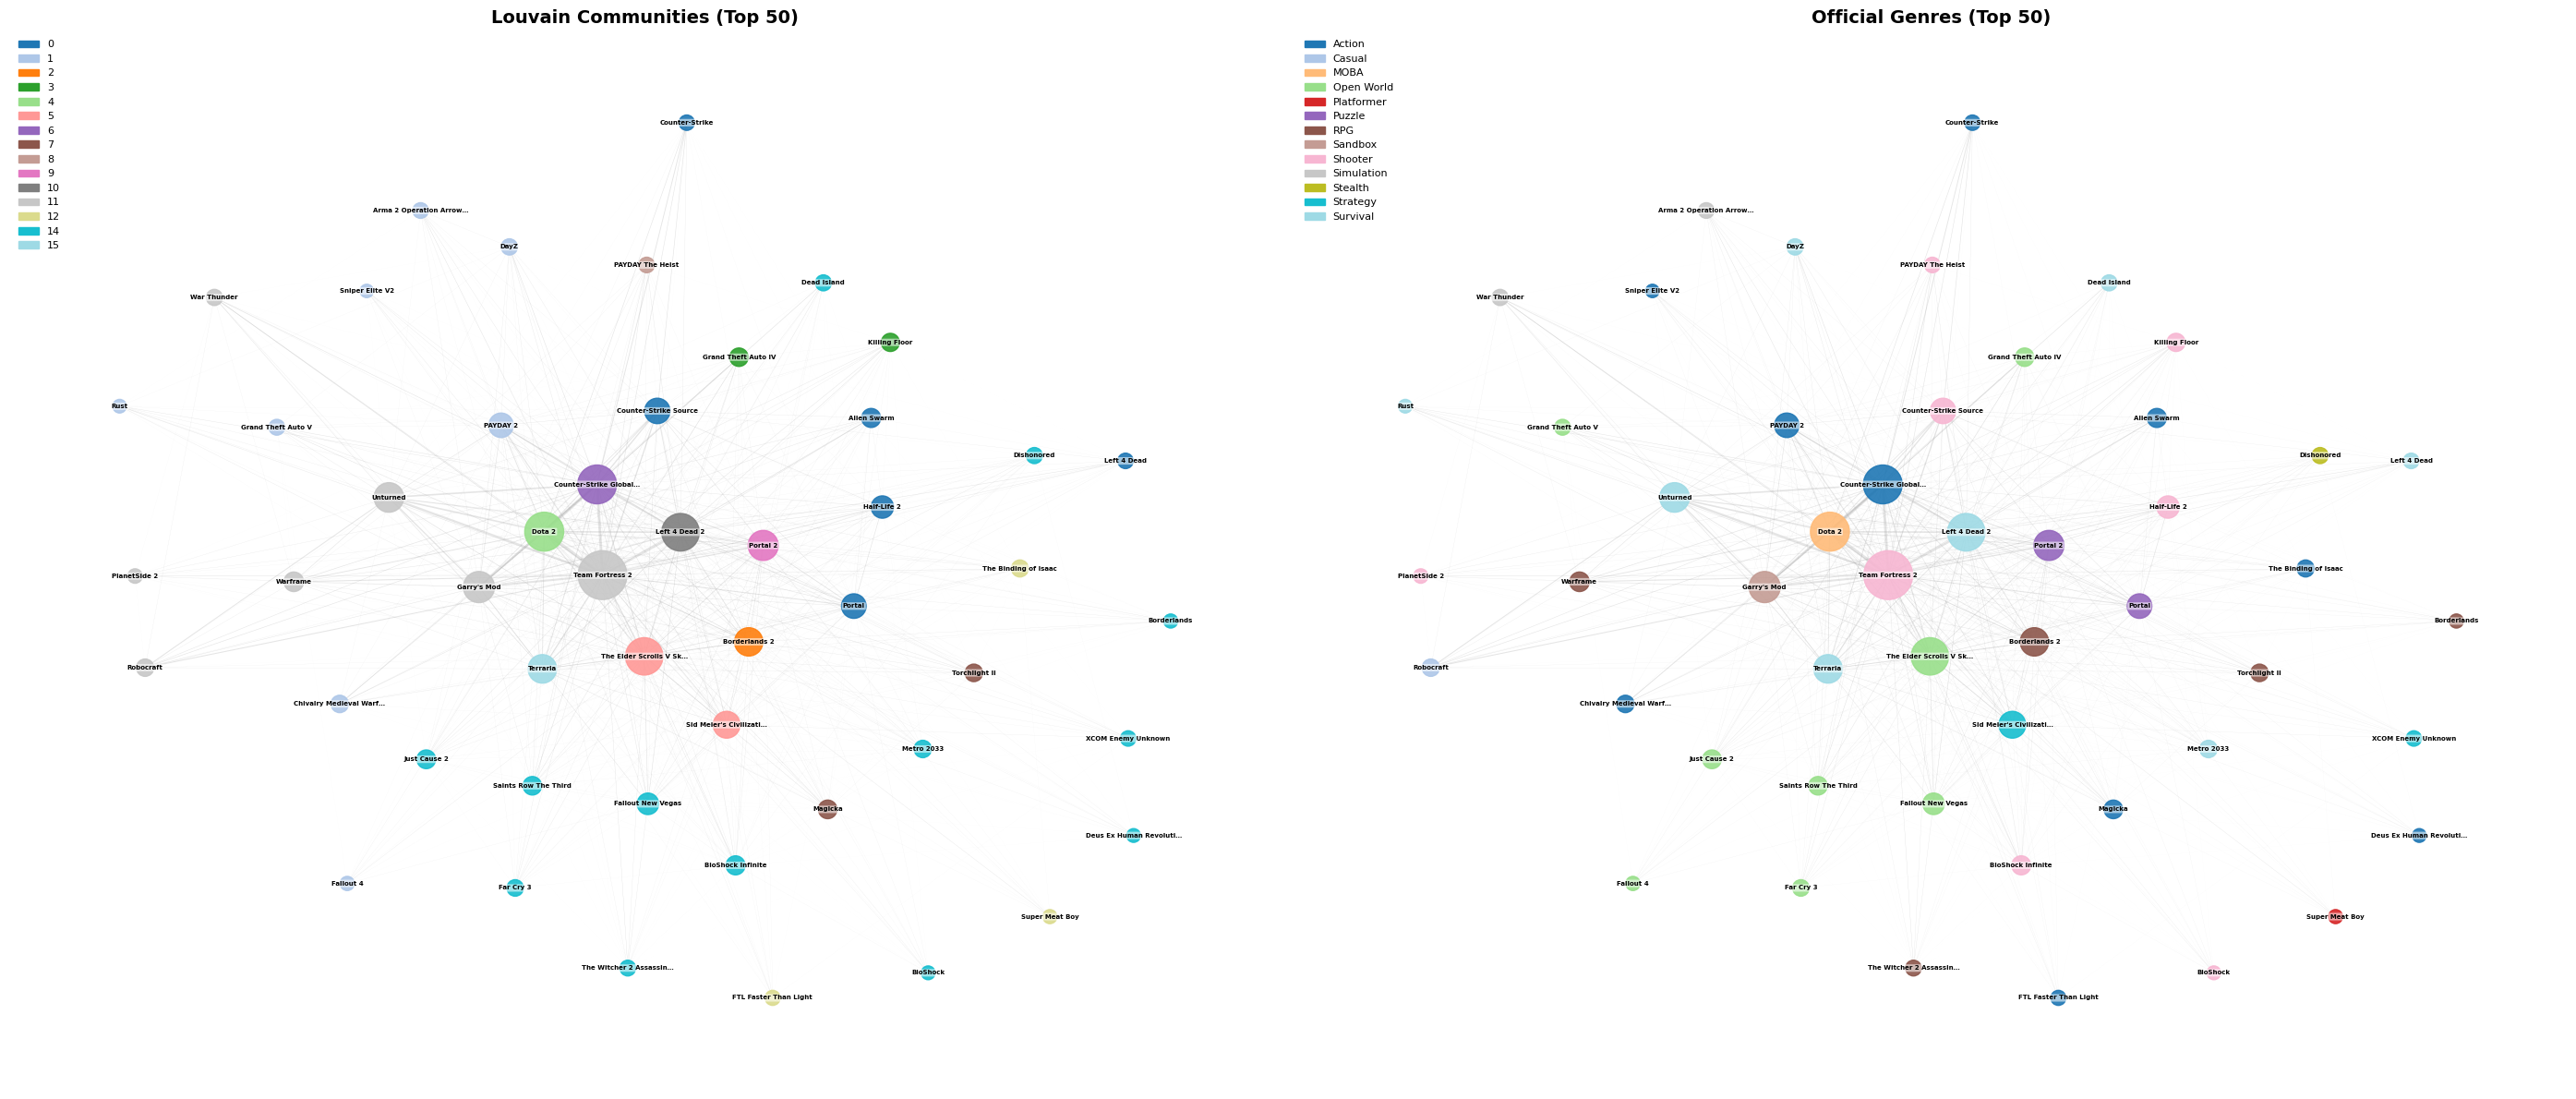

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Focus on fewer nodes to reduce clutter
TOP_N_VISIBLE = 50
top_nodes_50 = sorted(pagerank, key=pagerank.get, reverse=True)[:TOP_N_VISIBLE]
Gv_50 = G.subgraph(top_nodes_50).copy()

# High spacing layout
pos_clear = nx.spring_layout(
    Gv_50,
    pos={n: pos_init[n] for n in top_nodes_50},
    k=3.0,
    iterations=200,
    seed=42,
    weight='weight'
)

fig, axes = plt.subplots(1, 2, figsize=(28, 12))

# Graph 1: Louvain Communities
draw_graph(
    Gv_50,
    pos_clear,
    'louvain',
    f'Louvain Communities (Top {TOP_N_VISIBLE})',
    axes[0]
)

# Graph 2: Original Genres
draw_graph(
    Gv_50,
    pos_clear,
    'genre',
    f'Official Genres (Top {TOP_N_VISIBLE})',
    axes[1]
)

plt.tight_layout()
plt.show()

In [ ]:
# Evaluation using Normalized Mutual Information (NMI)
# NMI measures how much the detected communities overlap with the genre/tag labels
# Score: 0 = no overlap at all,  1 = perfect match
# We evaluate both Louvain and Girvan-Newman against Steam tags

nodes   = list(G.nodes)
genres  = [G.nodes[n]['genre']         for n in nodes]
louvain = [G.nodes[n]['louvain']        for n in nodes]
gn      = [G.nodes[n]['girvan_newman']  for n in nodes]

genre_enc = LabelEncoder().fit_transform(genres)

nmi_louvain = normalized_mutual_info_score(genre_enc, louvain)
nmi_gn      = normalized_mutual_info_score(genre_enc, gn)

# Summary table
print('=' * 55)
print(f'{"Algorithm":<20} {"NMI":>6}  {"Modularity":>10}  {"Runtime":>9}')
print('-' * 55)
print(f'{"Louvain":<20} {nmi_louvain:>6.4f}  {louvain_mod:>10.4f}  {louvain_time:>8.2f}s')
print(f'{"Girvan-Newman":<20} {nmi_gn:>6.4f}  {gn_mod:>10.4f}  {gn_time:>8.1f}s')
print('=' * 55)

print()
print('Interpretation:')
print(f'  Louvain modularity ({louvain_mod:.4f}) vs Girvan-Newman ({gn_mod:.4f}):')
print(f'  Higher modularity = communities are more internally dense.')
print()
print(f'  NMI Louvain={nmi_louvain:.4f} — communities have only partial overlap with tags.')
print(f'  This is expected: highly popular games (TF2, Dota 2, CS:GO) are played')
print(f'  across all genres, so they act as bridges that merge genre-distinct games')
print(f'  into the same community based on shared player base rather than game type.')
print()
print(f'  Girvan-Newman NMI={nmi_gn:.4f} — lower than Louvain, and took {gn_time/louvain_time:.0f}x longer.')
print(f'  For large dense graphs, Louvain is clearly the better practical choice.')

print()
if nmi_louvain > 0.3:
    print('Strong alignment: player behavior communities closely match genre labels.')
elif nmi_louvain > 0.1:
    print('Moderate alignment: partial overlap - player behavior reveals patterns beyond genre.')
else:
    print('Weak alignment: communities from player behavior diverge from official genre labels.')

# Louvain community genre breakdown
print('\nLouvain community breakdown:')
for cid in sorted(set(louvain)):
    members = [n for n in nodes if G.nodes[n]['louvain'] == cid]
    top_tags = pd.Series([G.nodes[n]['genre'] for n in members]).value_counts().head(3)
    summary = ', '.join(f'{g}({c})' for g, c in top_tags.items())
    print(f'  Community {cid:2d} ({len(members):3d} games): {summary}')

Algorithm               NMI  Modularity    Runtime
-------------------------------------------------------
Louvain              0.2996      0.1117      0.05s
Girvan-Newman        0.1045     -0.0000      11.9s

Interpretation:
  Louvain modularity (0.1117) vs Girvan-Newman (-0.0000):
  Higher modularity = communities are more internally dense.

  NMI Louvain=0.2996 — communities have only partial overlap with tags.
  This is expected: highly popular games (TF2, Dota 2, CS:GO) are played
  across all genres, so they act as bridges that merge genre-distinct games
  into the same community based on shared player base rather than game type.

  Girvan-Newman NMI=0.1045 — lower than Louvain, and took 219x longer.
  For large dense graphs, Louvain is clearly the better practical choice.

Moderate alignment: partial overlap - player behavior reveals patterns beyond genre.

Louvain community breakdown:
  Community  0 ( 25 games): Shooter(11), Action(6), RPG(2)
  Community  1 ( 20 games): Action(

In [ ]:
# Community Profiles
# What does each Louvain community actually represent?
# Top 5 games by PageRank per community reveal the "identity" of the cluster.

print('Community profiles — top 5 games by PageRank:\n')
for cid in sorted(set(louvain_partition.values())):
    members  = [n for n in G.nodes if G.nodes[n]['louvain'] == cid]
    top_games = sorted(members, key=lambda n: pagerank[n], reverse=True)[:5]
    dominant  = pd.Series([G.nodes[n]['genre'] for n in members]).value_counts().index[0]
    print(f'Community {cid} ({len(members)} games) — dominant tag: {dominant}')
    for g in top_games:
        print(f'    {g:<45} [{G.nodes[g]["genre"]}]')
    print()

# Community 3 is the smallest — show all games to understand why it is isolated
small = sorted(set(louvain_partition.values()), key=lambda c: sum(1 for n in G.nodes if G.nodes[n]['louvain'] == c))
smallest_cid = small[0]
c_members = [n for n in G.nodes if G.nodes[n]['louvain'] == smallest_cid]
print(f'Smallest community ({smallest_cid}) — all {len(c_members)} games:')
for g in sorted(c_members, key=lambda n: pagerank[n], reverse=True):
    deg = G.degree(g)
    print(f'  {g:<45} [{G.nodes[g]["genre"]}]  degree={deg}')

Community profiles — top 5 games by PageRank:

Community 0 (25 games) — dominant tag: Shooter
    Counter-Strike Source                         [Shooter]
    Portal                                        [Puzzle]
    Half-Life 2                                   [Shooter]
    Alien Swarm                                   [Action]
    Left 4 Dead                                   [Survival]

Community 1 (20 games) — dominant tag: Action
    PAYDAY 2                                      [Action]
    Chivalry Medieval Warfare                     [Action]
    DayZ                                          [Survival]
    Grand Theft Auto V                            [Open World]
    Arma 2 Operation Arrowhead                    [Simulation]

Community 2 (5 games) — dominant tag: RPG
    Borderlands 2                                 [RPG]
    South Park The Stick of Truth                 [RPG]
    Borderlands The Pre-Sequel                    [Looter Shooter]
    Titan Quest                  